# FWI · Elastic · Marmousi

End-to-end Elastic FWI on Marmousi II. **`vp`, `vs`, and `rho` come straight
from `sweep.datasets`** (Marmousi II ships all three) — we don't derive `vs`
from `vp` via Poisson or `rho` via Gardner anymore.

All three parameters `vp`, `vs`, and `rho` are inverted jointly.

1. load embedded `(vp, vs, rho)` true + smooth models from `sweep.datasets`
2. build geometry, wavelet, and Elastic solver (`impl='c'`)
3. forward-model the observed two-component data (`vx`, `vz`)
4. stochastic Adam: random mini-batch of shots per iter
5. show `vp`, `vs`, `rho` inverted vs. true vs. initial

## Note on amplitudes / Adam `eps`

Elastic `vz` traces with a unit-amplitude Ricker source are ~1e-7. That makes
the MSE loss ~1e-17 and Adam can't escape the `eps` floor. We multiply the
wavelet by `1e6` to push the loss back to O(1) and use `eps=1e-16` to keep
small residual gradients responsive.


## 1. Parameters

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Elastic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker
from sweep.datasets import load_marmousi, MARMOUSI_DH

dh    = MARMOUSI_DH * 2   # 25 m (12.5 m → 25 m via ::2,::2 downsample)
dt    = 0.0016            # elastic CFL at 25 m
nt    = 5000              # 8.0 s — the full spread spans 15+ km from the
                          # edge shots; the far-offset diving waves (and,
                          # with a free surface, the multiple train) need
                          # ~8 s to arrive
freq  = 5.0
delay = 0.22
nshots, nrec, batch_shots = 20, 80, 8
src_z, rec_z = 2, 4

lr_vp, lr_vs, lr_rho = 25.0, 15.0, 8.0
n_iter = 30

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 2. Load the (vp, vs, rho) triplet from sweep.datasets

Marmousi II includes a real shear-wave model (water layer has `vs=0`), so we
no longer fake `vs` from `vp`. `rho` is in kg/m³.

shape: (141, 681)   physical: 3.5 km depth × 17.0 km offset


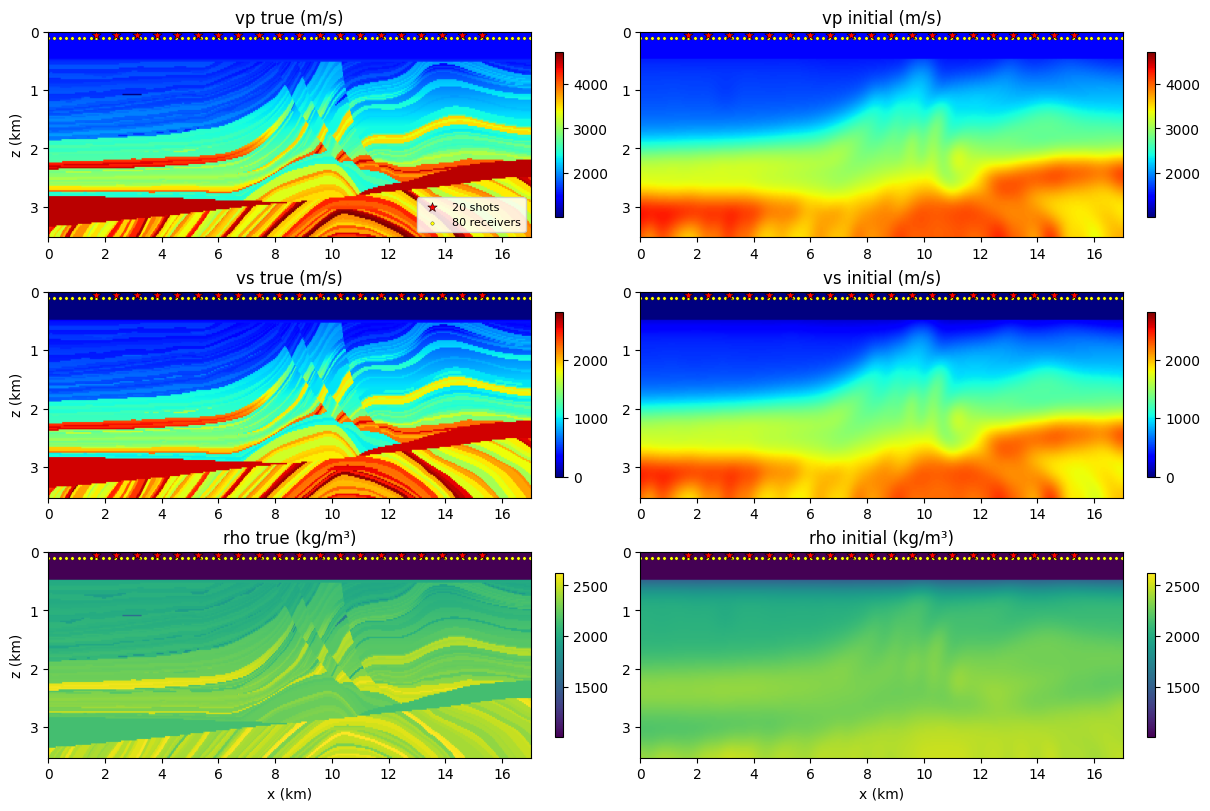

In [2]:
# Full 12.5 m presets, then ::2,::2 downsample to 25 m
vp_true_np  = load_marmousi('vp_true')[::2, ::2].copy()
vs_true_np  = load_marmousi('vs_true')[::2, ::2].copy()
rho_true_np = load_marmousi('rho_true')[::2, ::2].copy()

vp_init_np  = load_marmousi('vp_smooth')[::2, ::2].copy()
vs_init_np  = load_marmousi('vs_smooth')[::2, ::2].copy()
rho_init_np = load_marmousi('rho_smooth')[::2, ::2].copy()

# The smoothing bled sediment velocities into the water column (and water
# velocity into the shallow sediments).  The water properties are KNOWN in a
# marine survey, so restore them in the initial model instead of starting
# from a physically wrong water column.
water_np = vs_true_np == 0.0
vp_init_np[water_np] = vp_true_np[water_np]
vs_init_np[water_np] = 0.0
rho_init_np[water_np] = rho_true_np[water_np]

shape = vp_true_np.shape
print('shape:', shape, '  physical:',
      f'{shape[0]*dh/1000:.1f} km depth × {shape[1]*dh/1000:.1f} km offset')

# Acquisition geometry: surface sources + horizontal receiver line
src_x = np.linspace(shape[1] * 0.1, shape[1] * 0.9, nshots).astype(np.int64)
rec_x = np.linspace(0, shape[1] - 1, nrec).astype(np.int64)
src_x_km = src_x * dh / 1000;  src_z_km = src_z * dh / 1000
rec_x_km = rec_x * dh / 1000;  rec_z_km = rec_z * dh / 1000

fig, axes = plt.subplots(3, 2, figsize=(12, 8), constrained_layout=True)
for row, (label, t_arr, i_arr, cmap, unit) in enumerate([
    ('vp',  vp_true_np,  vp_init_np,  'jet',      'm/s'),
    ('vs',  vs_true_np,  vs_init_np,  'jet',      'm/s'),
    ('rho', rho_true_np, rho_init_np, 'viridis',  'kg/m³'),
]):
    vmin = float(min(t_arr.min(), i_arr.min())); vmax = float(max(t_arr.max(), i_arr.max()))
    for col, (arr, suffix) in enumerate([(t_arr, 'true'), (i_arr, 'initial')]):
        ax = axes[row, col]
        im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto',
                       extent=[0, shape[1]*dh/1000, shape[0]*dh/1000, 0])
        ax.scatter(rec_x_km, np.full_like(rec_x_km, rec_z_km, dtype=float),
                   s=6, c='yellow', edgecolors='k', linewidths=0.2)
        ax.scatter(src_x_km, np.full_like(src_x_km, src_z_km, dtype=float),
                   s=50, c='red', marker='*', edgecolors='k', linewidths=0.4)
        ax.set_title(f'{label} {suffix} ({unit})')
        if col == 0: ax.set_ylabel('z (km)')
        if row == 2: ax.set_xlabel('x (km)')
        fig.colorbar(im, ax=ax, shrink=0.8)
# legend on the top-left panel only
axes[0, 0].scatter([], [], s=50, c='red', marker='*', edgecolors='k',
                   linewidths=0.4, label=f'{nshots} shots')
axes[0, 0].scatter([], [], s=6, c='yellow', edgecolors='k', linewidths=0.2,
                   label=f'{nrec} receivers')
axes[0, 0].legend(loc='lower right', fontsize=8, framealpha=0.85)
plt.show()


## 3. Geometry, wavelet, solver

Zero-parameter solver — `pml_type`, `source_type`, `receiver_type`,
`use_ckpt`, `spatial_order`, `abcn`, `free_surface` all default. Elastic's
defaults: `pml_type='cpmls'`, `source_type=['sxx','szz']`,
`receiver_type=['vx','vz']`.

In [3]:
t = np.arange(nt, dtype=np.float32) * dt
wavelet = 1e6 * ricker(t - delay, f=freq)   # rescale (see top-of-notebook note)

sources   = np.stack([src_x, np.full(nshots, src_z, dtype=np.int64)], axis=1)
receivers = np.stack([rec_x, np.full(nrec, rec_z, dtype=np.int64)], axis=1)
receivers = np.repeat(receivers[None, ...], nshots, axis=0)

equation = Elastic(device=device)
solver   = PropTorch(equation, shape=shape, dh=dh, dt=dt, impl='c')
# eager-mode chunk autograd holds activations for a full chunk; shrink the
# stochastic mini-batch when the C path is unavailable so memory stays low.
if solver.impl == 'eager':
    batch_shots = min(batch_shots, 2)
print('impl:', solver.impl, ' batch_shots:', batch_shots)


impl: c  batch_shots: 8


### Aside · which sources and receivers does this equation accept?

`Elastic` publishes a structured field table — query `eq.models` for the
expected model input order, `available_source_fields()` / `available_receiver_fields()`
for valid source / receiver options. See the
[Equations user guide](../../user-guide/equations/) for the full rundown.

In [4]:
print('models (input order matters!):')
for spec in equation.MODEL_SPECS:
    unit = f' [{spec.unit}]' if spec.unit else ''
    print(f'  - {spec.name:8s}{unit}  — {spec.description}')
print('defaults  :', equation.default_source_fields, '/', equation.default_receiver_fields)
print('receivers :')
for spec in equation.available_receiver_fields():
    print(f'  - {spec.name:8s} aliases={spec.aliases}  — {spec.description}')

models (input order matters!):
  - vp       [m/s]  — Elastic P-wave velocity model.
  - vs       [m/s]  — Elastic S-wave velocity model.
  - rho      [kg/m^3]  — Density model.
defaults  : ['sxx', 'szz'] / ['vx', 'vz']
receivers :
  - vx       aliases=('velocity_x',)  — Particle velocity in the x direction.
  - vz       aliases=('velocity_z',)  — Particle velocity in the z direction.
  - sxx      aliases=('stress_xx',)  — Normal stress in the x direction.
  - szz      aliases=('stress_zz',)  — Normal stress in the z direction.


## 4. Forward modeling — observed vz gather

observed shape: (20, 5000, 80, 2)


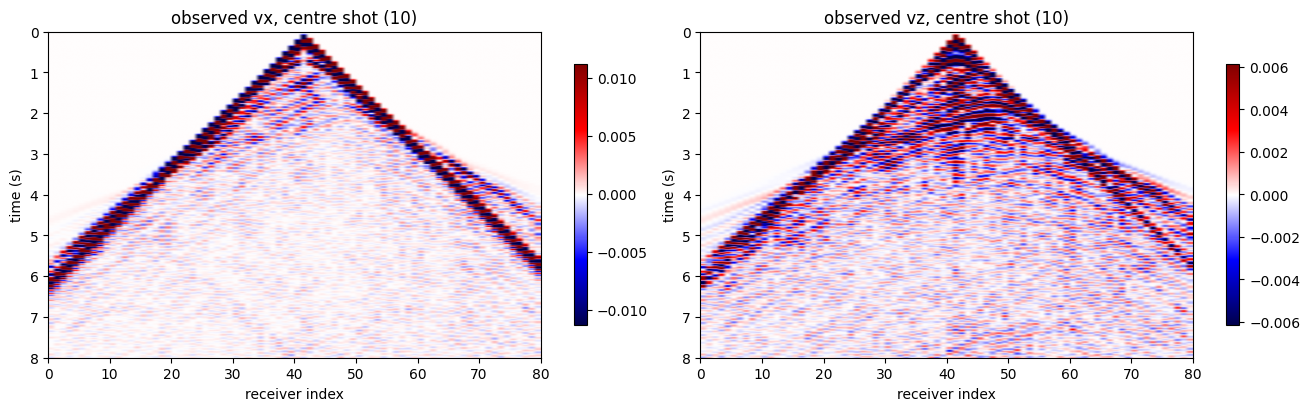

In [5]:
vp_true  = torch.tensor(vp_true_np,  device=device)
vs_true  = torch.tensor(vs_true_np,  device=device)
rho_true = torch.tensor(rho_true_np, device=device)
models_true = [vp_true, vs_true, rho_true]

with torch.no_grad():
    observed = solver(wavelet, sources, receivers, models=models_true).detach()
print('observed shape:', tuple(observed.shape))

centre = nshots // 2
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for ax, comp, name in zip(axes, [0, 1], ['vx', 'vz']):
    gather = observed[centre, :, :, comp].detach().cpu().numpy()
    vmin, vmax = np.percentile(gather, [2, 98])
    im = ax.imshow(gather, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto',
                   extent=[0, nrec, nt * dt, 0])
    ax.set_xlabel('receiver index'); ax.set_ylabel('time (s)')
    ax.set_title(f'observed {name}, centre shot ({centre})')
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()


## 5. Stochastic Adam loop — invert vp and vs (rho fixed)

Each iteration samples a random mini-batch of `batch_shots` shots. `vp` and
`vs` get their own learning rates (`vs` slightly lower); `rho` stays frozen.

The **water column is pinned to its true properties** every iteration
(`vs_true == 0` marks the water): in a marine survey the water depth and
velocity are known, and letting the inversion drift them only pollutes
the model — the standard practice is to hold them fixed.


In [6]:
import time
rng = np.random.default_rng(0)
t_start = time.time()
vp_var  = torch.tensor(vp_init_np,  device=device, requires_grad=True)
vs_var  = torch.tensor(vs_init_np,  device=device, requires_grad=True)
rho_var = torch.tensor(rho_init_np, device=device, requires_grad=True)

# the water column (vs == 0 in Marmousi II) is known — pin it
water_mask = torch.tensor(vs_true_np == 0.0, device=device)
with torch.no_grad():
    vp_var[water_mask] = vp_true[water_mask]
    vs_var[water_mask] = 0.0
    rho_var[water_mask] = rho_true[water_mask]

optimizer = torch.optim.Adam([
    {'params': [vp_var],  'lr': lr_vp},
    {'params': [vs_var],  'lr': lr_vs},
    {'params': [rho_var], 'lr': lr_rho},
], eps=1e-16)
losses = []

for it in range(n_iter):
    iter_t0 = time.time()
    idx = rng.choice(nshots, size=batch_shots, replace=False)
    optimizer.zero_grad()
    predicted = solver(wavelet, sources[idx], receivers[idx], models=[vp_var, vs_var, rho_var])
    loss = (predicted - observed[idx]).pow(2).mean()
    loss.backward()
    optimizer.step()
    # Pin the known water column; keep vs non-negative and rho positive
    with torch.no_grad():
        vp_var[water_mask] = vp_true[water_mask]
        vs_var[water_mask] = 0.0
        rho_var[water_mask] = rho_true[water_mask]
        vs_var.clamp_(min=0.0)
        rho_var.clamp_(min=100.0)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    iter_t = time.time() - iter_t0
    losses.append(float(loss.detach().cpu()))
    print(f'iter {it:02d}  loss {losses[-1]:.4e}  iter={iter_t:.2f}s  total={time.time()-t_start:.1f}s')


iter 00  loss 9.7001e-06  iter=2.89s  total=3.0s


iter 01  loss 7.2735e-06  iter=2.70s  total=5.7s


iter 02  loss 5.5832e-06  iter=2.70s  total=8.4s


iter 03  loss 4.6892e-06  iter=2.71s  total=11.1s


iter 04  loss 3.6051e-06  iter=2.71s  total=13.8s


...

iter 25  loss 1.1509e-06  iter=2.74s  total=71.1s


iter 26  loss 1.0343e-06  iter=2.75s  total=73.9s


iter 27  loss 1.0949e-06  iter=2.75s  total=76.6s


iter 28  loss 9.7786e-07  iter=2.74s  total=79.4s


iter 29  loss 9.7055e-07  iter=2.75s  total=82.1s


## 6. Results

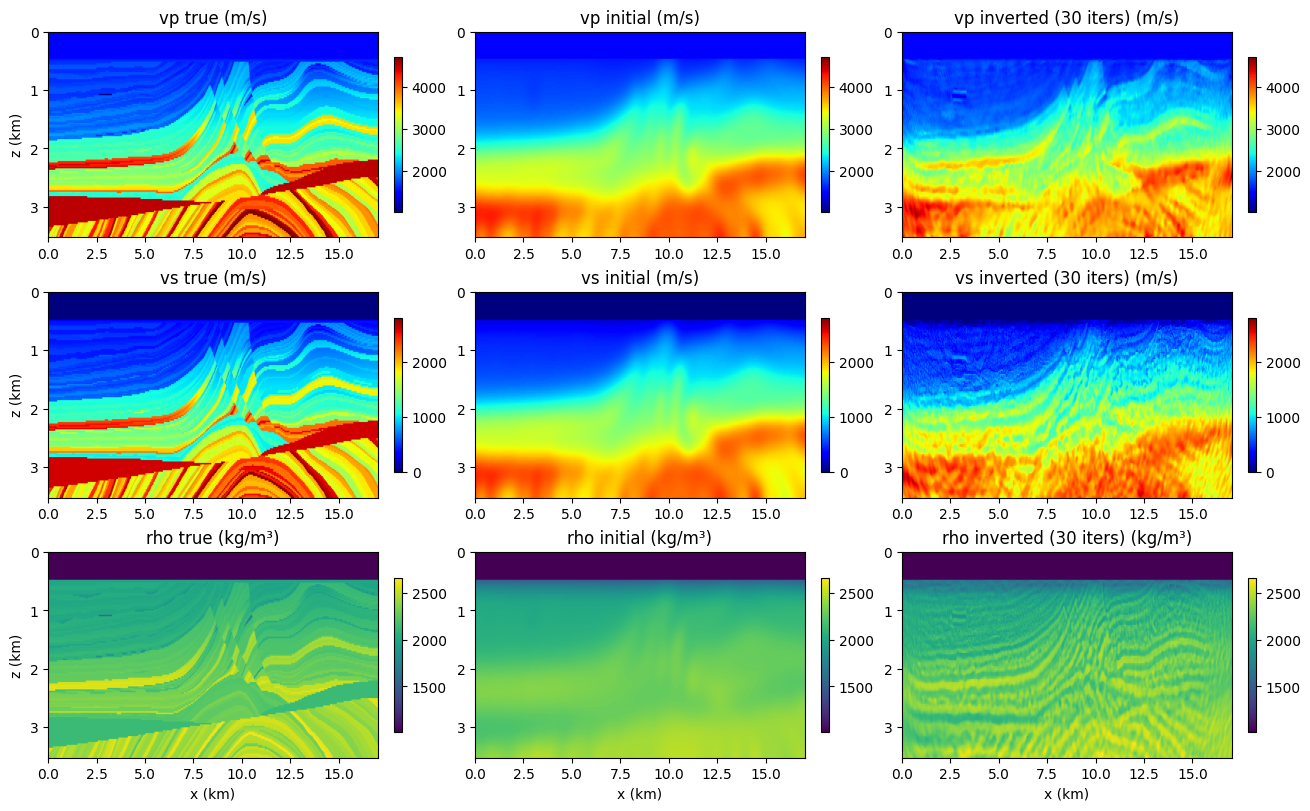

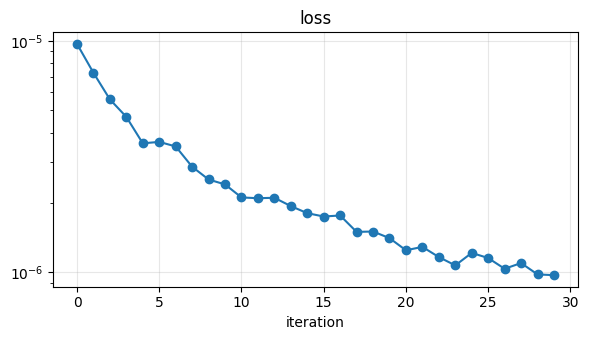

In [7]:
vp_final  = vp_var.detach().cpu().numpy()
vs_final  = vs_var.detach().cpu().numpy()
rho_final = rho_var.detach().cpu().numpy()

fig, axes = plt.subplots(3, 3, figsize=(13, 8), constrained_layout=True)
for row, (label, t_arr, i_arr, f_arr, cmap, unit) in enumerate([
    ('vp',  vp_true_np,  vp_init_np,  vp_final,  'jet',     'm/s'),
    ('vs',  vs_true_np,  vs_init_np,  vs_final,  'jet',     'm/s'),
    ('rho', rho_true_np, rho_init_np, rho_final, 'viridis', 'kg/m³'),
]):
    vmin = float(min(t_arr.min(), i_arr.min(), f_arr.min()))
    vmax = float(max(t_arr.max(), i_arr.max(), f_arr.max()))
    for col, (arr, title) in enumerate([
        (t_arr, f'{label} true'),
        (i_arr, f'{label} initial'),
        (f_arr, f'{label} inverted ({n_iter} iters)'),
    ]):
        im = axes[row, col].imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto',
                                   extent=[0, shape[1]*dh/1000, shape[0]*dh/1000, 0])
        axes[row, col].set_title(f'{title} ({unit})')
        if col == 0: axes[row, col].set_ylabel('z (km)')
        if row == 2: axes[row, col].set_xlabel('x (km)')
        fig.colorbar(im, ax=axes[row, col], shrink=0.75)
plt.show()

plt.figure(figsize=(6, 3.5))
plt.plot(losses, marker='o')
plt.title('loss'); plt.xlabel('iteration')
plt.yscale('log'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 7. Free-surface variant — the same inversion with surface physics on

Everything above ran with the default absorbing top. Marmousi II is a marine
model, so the physically complete setup has a **free surface at the sea
surface** — and that is a one-argument change:

```python
solver_fs = PropTorch(equation, shape=shape, dh=dh, dt=dt, impl='c',
                      free_surface=True)
```

With the free surface on, the observed data gain the source/receiver ghosts
and the whole train of surface-related multiples, and the adjoint carries the
same boundary condition into the gradient. The data are richer; the inverse
problem is correspondingly harder — for production work pair this with a
multiscale schedule ([notebook 03](03_fwi_multiscale.ipynb)). A per-edge form
is also available (any subset of the four faces —
[notebook 24](24_wavefield_per_edge_free_surface.ipynb)).

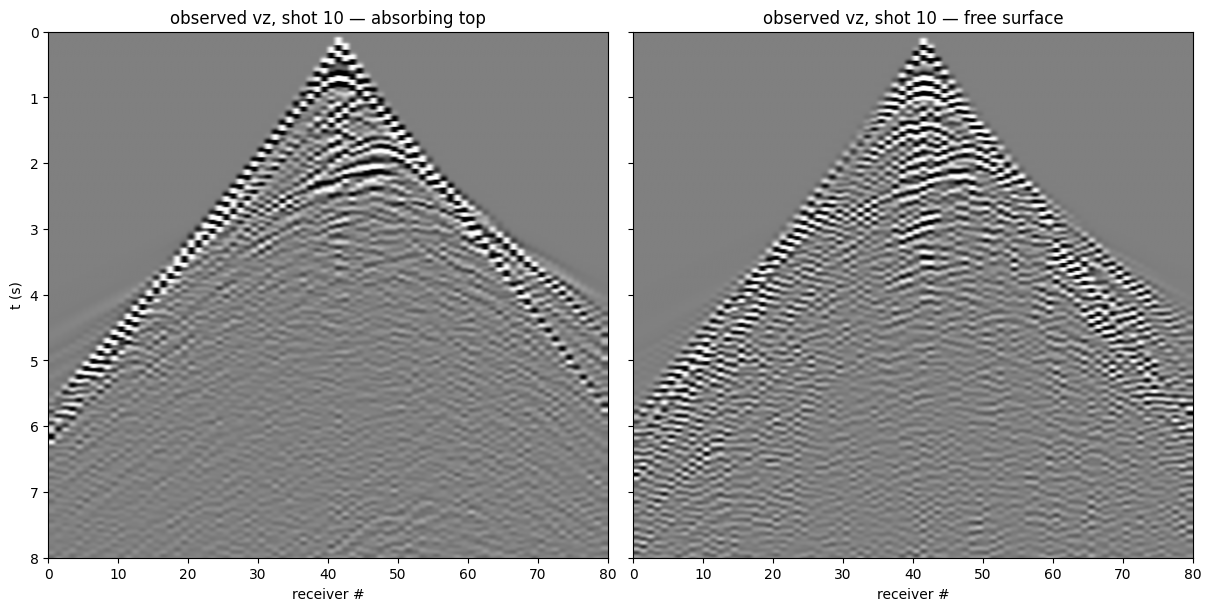

In [8]:
solver_fs = PropTorch(equation, shape=shape, dh=dh, dt=dt, impl=solver.impl,
                      free_surface=True)
with torch.no_grad():
    observed_fs = solver_fs(wavelet, sources, receivers, models=models_true)

# observed record layout: (nshots, nt, nrec, [vx, vz]) -> vz gather
shot = nshots // 2
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True, sharey=True)
for ax, (dat, ttl) in zip(axes, [(observed, 'absorbing top'),
                                 (observed_fs, 'free surface')]):
    g = dat[shot, :, :, 1].detach().cpu().numpy()
    clip = np.percentile(np.abs(g), 97)
    ax.imshow(g, aspect='auto', cmap='gray', vmin=-clip, vmax=clip,
              extent=(0, g.shape[1], nt * dt, 0))
    ax.set_title(f'observed vz, shot {shot} — {ttl}')
    ax.set_xlabel('receiver #')
axes[0].set_ylabel('t (s)')
plt.show()

The free-surface gather rings far longer: every primary is followed by its
ghost and a train of surface multiples. The first vp gradient shows the same
story — extra reflectivity everywhere, and stronger shallow energy:

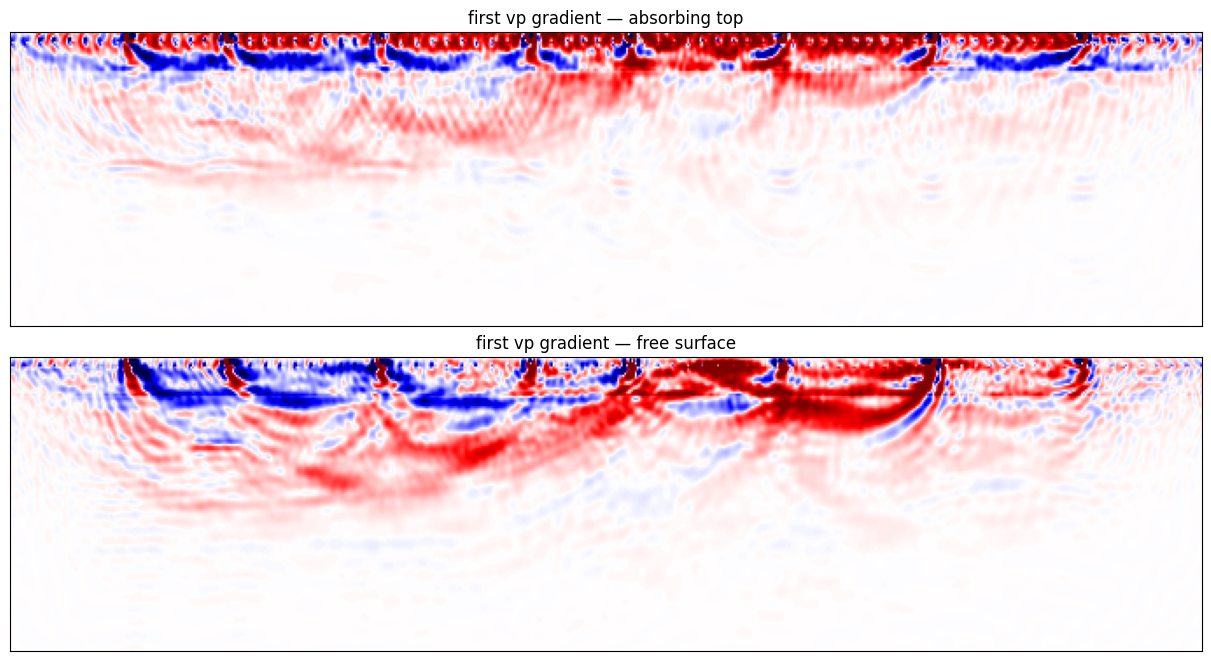

In [9]:
def first_vp_gradient(sol, obs_ref):
    vp_g = torch.tensor(vp_init_np, device=device, requires_grad=True)
    m = [vp_g, torch.tensor(vs_init_np, device=device),
         torch.tensor(rho_init_np, device=device)]
    # evenly spread shots across the line — a leading block of
    # shots would only illuminate the left part of the model
    idx = np.linspace(0, nshots - 1, batch_shots).astype(int)
    pred = sol(wavelet, sources[idx], receivers[idx], models=m)
    (pred - obs_ref[idx]).pow(2).mean().backward()
    return vp_g.grad.detach().cpu().numpy()

g_abs = first_vp_gradient(solver, observed)
g_fs = first_vp_gradient(solver_fs, observed_fs)

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), constrained_layout=True)
for ax, (g, ttl) in zip(axes, [(g_abs, 'absorbing top'), (g_fs, 'free surface')]):
    clip = np.percentile(np.abs(g), 99)
    ax.imshow(g, cmap='seismic', vmin=-clip, vmax=clip, aspect='auto')
    ax.set_title(f'first vp gradient — {ttl}')
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

The same 30-iteration Adam run (identical hyper-parameters) confirms the
free-surface inversion is well-behaved — the loss decreases monotonically
just like the absorbing run, at the same iteration cost. (The two curves are normalized by their first
value: absolute losses are not comparable because the free-surface data
simply contain more energy.)

FS iter 00  loss 1.0339e-04


FS iter 01  loss 8.8191e-05


FS iter 02  loss 7.2496e-05


FS iter 03  loss 6.2722e-05


FS iter 04  loss 5.2795e-05


...

FS iter 25  loss 1.1759e-05


FS iter 26  loss 1.1114e-05


FS iter 27  loss 1.0119e-05


FS iter 28  loss 1.0354e-05


FS iter 29  loss 1.0010e-05


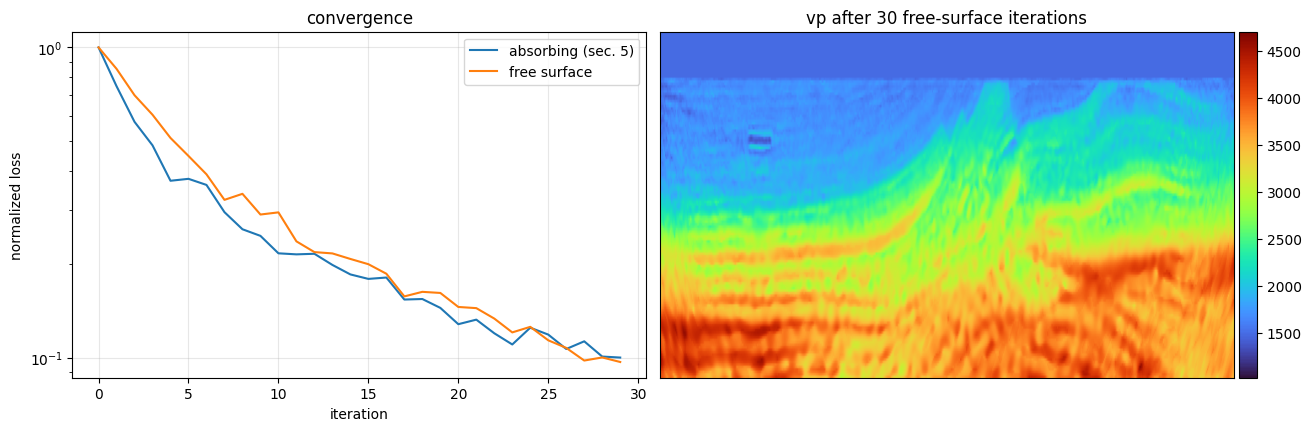

In [10]:
vp_fs  = torch.tensor(vp_init_np,  device=device, requires_grad=True)
vs_fs  = torch.tensor(vs_init_np,  device=device, requires_grad=True)
rho_fs = torch.tensor(rho_init_np, device=device, requires_grad=True)
with torch.no_grad():
    vp_fs[water_mask] = vp_true[water_mask]
    vs_fs[water_mask] = 0.0
    rho_fs[water_mask] = rho_true[water_mask]

opt_fs = torch.optim.Adam([
    {'params': [vp_fs],  'lr': lr_vp},
    {'params': [vs_fs],  'lr': lr_vs},
    {'params': [rho_fs], 'lr': lr_rho},
], eps=1e-16)

losses_fs = []
for it in range(n_iter):
    idx = rng.choice(nshots, size=batch_shots, replace=False)
    opt_fs.zero_grad()
    pred = solver_fs(wavelet, sources[idx], receivers[idx],
                     models=[vp_fs, vs_fs, rho_fs])
    loss = (pred - observed_fs[idx]).pow(2).mean()
    loss.backward()
    opt_fs.step()
    with torch.no_grad():
        vp_fs[water_mask] = vp_true[water_mask]
        vs_fs[water_mask] = 0.0
        rho_fs[water_mask] = rho_true[water_mask]
        vs_fs.clamp_(min=0.0)
        rho_fs.clamp_(min=100.0)
    losses_fs.append(float(loss.detach().cpu()))
    print(f'FS iter {it:02d}  loss {losses_fs[-1]:.4e}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), constrained_layout=True)
axes[0].semilogy(np.array(losses) / losses[0], label='absorbing (sec. 5)')
axes[0].semilogy(np.array(losses_fs) / losses_fs[0], label='free surface')
axes[0].set_xlabel('iteration'); axes[0].set_ylabel('normalized loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('convergence')
clip_v = (vp_true_np.min(), vp_true_np.max())
im = axes[1].imshow(vp_fs.detach().cpu().numpy(), cmap='turbo',
                    vmin=clip_v[0], vmax=clip_v[1], aspect='auto')
axes[1].set_title(f'vp after {n_iter} free-surface iterations')
axes[1].set_xticks([]); axes[1].set_yticks([])
fig.colorbar(im, ax=axes[1], pad=0.01)
plt.show()

## Reference

Virieux, J. (1986). P-SV wave propagation in heterogeneous media: Velocity-stress finite-difference method. *Geophysics, 51*(4), 889–901. [doi:10.1190/1.1442147](https://doi.org/10.1190/1.1442147) — the staggered-grid elastic wave equation used here.

---

<p><strong>Download this notebook</strong> &mdash; <a href="02_fwi_elastic_marmousi.ipynb" download><code>02_fwi_elastic_marmousi.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/02_fwi_elastic_marmousi.ipynb">view on GitHub</a></p>